In [8]:
import os

print(os.listdir("./data_madrid"))

['dataset-copy.csv', 'dataset.csv']


In [9]:
import os
import pandas as pd
import sys
print(sys.executable)
data_madrid = pd.read_csv(r"data_madrid/dataset-copy.csv")

/Users/rup/Documents/SaturdayAI/saturdayTesting/.venv/bin/python3


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("./data_madrid/dataset-copy.csv")

print(df.info())

# plt.figure(figsize=(10, 6))
# sns.histplot(df['PrecioActual'], bins=50, kde=True)
# plt.title('Distribución de Precios en Idealista Madrid')
# plt.show()


<class 'pandas.DataFrame'>
RangeIndex: 11826 entries, 0 to 11825
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   provincia       11826 non-null  str    
 1   zona            11826 non-null  str    
 2   titulo          11826 non-null  str    
 3   PrecioActual    11826 non-null  int64  
 4   PrecioAnterior  11826 non-null  int64  
 5   metros          11826 non-null  int64  
 6   habitaciones    11460 non-null  float64
 7   ascensor        11033 non-null  str    
 8   localizacion    10730 non-null  str    
 9   planta          10601 non-null  str    
 10  baños           11826 non-null  int64  
 11  tags            11664 non-null  str    
 12  descripcion     11761 non-null  str    
 13  Enlace          11826 non-null  str    
dtypes: float64(1), int64(4), str(9)
memory usage: 1.3 MB
None


In [11]:
import os
from IPython.display import display


for root, dirs, files in os.walk("."):
    if "dataset-copy.csv" in files:
        file_path = os.path.join(root, "dataset.csv")
        print(f"Found it! Loading from: {file_path}")
        df = pd.read_csv(file_path)
        break
else:
    print("File not found in current directory or subdirectories.")

if 'df' in locals():
    pd.options.display.max_columns = None
    # display(df.head())

Found it! Loading from: ./data_madrid/dataset.csv


In [12]:
columns_to_use = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta", "PrecioActual", "baños"]
df = df[columns_to_use]

display(df.head())

,zona,metros,habitaciones,ascensor,localizacion,planta,PrecioActual,baños
0,ciudad-lineal,69,2.0,S,EXTERIOR,5ª,355000,1
1,carabanchel,91,3.0,N,EXTERIOR,1ª,149000,0
2,centro,36,1.0,S,NaN,2ª,195000,0
3,usera,58,1.0,S,INTERIOR,BAJO,195000,0
4,tetuan,140,3.0,S,EXTERIOR,2ª,715000,0


In [13]:
print(df.dtypes)

print(df.isnull().sum())

zona                str
metros            int64
habitaciones    float64
ascensor            str
localizacion        str
planta              str
PrecioActual      int64
baños             int64
dtype: object
zona               0
metros             0
habitaciones     366
ascensor         793
localizacion    1096
planta          1225
PrecioActual       0
baños              0
dtype: int64


In [14]:
# display(df.describe())

# print(df['zona'].value_counts())
# print(df['ascensor'].value_counts())


In [15]:
# missing_pct = df.isnull().mean() * 100

# columns_over_10pct = missing_pct[missing_pct > 10]
# print(columns_over_10pct)

In [16]:
# df['planta'] = df['planta'].fillna(df['planta'].median())

# print(df['planta'].isnull().sum())

In [17]:
# print(df['planta'].dtype)
# print(df['planta'].unique())


In [18]:
# Mapping for special floor values
floor_mapping = {
    'BAJO': 0,
    'SÓTANO': -1,
    'ENTREPLANTA': 0.5 
}

def convert_floor(x):
    if pd.isnull(x):
        return None
    x = str(x).strip()
    if x in floor_mapping:
        return floor_mapping[x]
    try:
        return int(x.replace('ª',''))
    except:
        return None

df['planta_num'] = df['planta'].apply(convert_floor)

# Fill missing values with median
df['planta_num'] = df['planta_num'].fillna(df['planta_num'].median())

print(df[['planta','planta_num']].head(15))


   planta  planta_num
0      5ª         5.0
1      1ª         1.0
2      2ª         2.0
3    BAJO         0.0
4      2ª         2.0
5      3ª         3.0
6      6ª         6.0
7      1ª         1.0
8     NaN         2.0
9      3ª         3.0
10     1ª         1.0
11    NaN         2.0
12     2ª         2.0
13     2ª         2.0
14     1ª         1.0


In [19]:

cols = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta", "PrecioActual", "baños"]
df = df[cols] 


floor_mapping = {'BAJO': 0, 'SÓTANO': -1, 'ENTREPLANTA': 0}

def convert_floor(x):
    if pd.isnull(x): return None
    x = str(x).strip().upper()
    if x in floor_mapping: return floor_mapping[x]
    try:
        return int(x.replace('ª',''))
    except:
        return None

df['planta_num'] = df['planta'].apply(convert_floor)

mediana = df['planta_num'].median()
df['planta_num'] = df['planta_num'].fillna(mediana).astype(int)

df['habitaciones'] = df['habitaciones'].fillna(0).astype(int)

df['baños'] = df['baños'].fillna(0).astype(int)

display(df.head())


,zona,metros,habitaciones,ascensor,localizacion,planta,PrecioActual,baños,planta_num
0,ciudad-lineal,69,2,S,EXTERIOR,5ª,355000,1,5
1,carabanchel,91,3,N,EXTERIOR,1ª,149000,0,1
2,centro,36,1,S,NaN,2ª,195000,0,2
3,usera,58,1,S,INTERIOR,BAJO,195000,0,0
4,tetuan,140,3,S,EXTERIOR,2ª,715000,0,2


In [20]:
df['habitaciones'] = df['habitaciones'].astype('Int64')

# df['localizacion'] = (df['localizacion'] == 'EXTERIOR').astype(int)
df['localizacion'] = (df['localizacion'].astype(str).str.upper() == 'EXTERIOR').astype(int)
df['localizacion'] = df['localizacion'].fillna(0).astype(int)

df['ascensor'] = df['ascensor'].replace({'s': 1, 'n': 0, 'S': 1, 'N': 0}).fillna(0).astype(int)

conteos = df['localizacion'].value_counts()

print(f"Exteriores (1): {conteos.get(1, 0)}")
print(f"Interiores (0): {conteos.get(0, 0)}")

# display(df[df['localizacion'] == 1].head(10))

Exteriores (1): 9087
Interiores (0): 2739


In [21]:
df['zona_id'] = df['zona'].astype('category').cat.codes

df['zona_id'] = df['zona_id'] + 1

display(df[['zona', 'zona_id']].drop_duplicates().head(10))

with pd.option_context('display.max_rows', None):
    display(df[['zona_id', 'zona']].drop_duplicates().sort_values('zona_id'))

,zona,zona_id
0,ciudad-lineal,8
1,carabanchel,4
2,centro,5
3,usera,18
4,tetuan,17
5,arganzuela,1
6,barrio-de-salamanca,3
7,puente-de-vallecas,14
8,moncloa,12
9,chamberi,7


,zona_id,zona
5,1,arganzuela
73,2,barajas
6,3,barrio-de-salamanca
1,4,carabanchel
2,5,centro
11,6,chamartin
9,7,chamberi
0,8,ciudad-lineal
18,9,fuencarral
36,10,hortaleza


In [22]:
columns_to_use = ["zona", "zona_id", "metros", "habitaciones", "ascensor", "localizacion", "planta_num", "baños", "PrecioActual"]
df = df[columns_to_use]

display(df.head(5))

,zona,zona_id,metros,habitaciones,ascensor,localizacion,planta_num,baños,PrecioActual
0,ciudad-lineal,8,69,2,1,1,5,1,355000
1,carabanchel,4,91,3,0,1,1,0,149000
2,centro,5,36,1,1,0,2,0,195000
3,usera,18,58,1,1,0,0,0,195000
4,tetuan,17,140,3,1,1,2,0,715000


In [23]:
df.columns = df.columns.str.strip()

In [24]:
print("Columnas detectadas:", df.columns.tolist())

Columnas detectadas: ['zona', 'zona_id', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta_num', 'baños', 'PrecioActual']


In [25]:
# df['localizacion'] = (df['localizacion'] == 'EXTERIOR').astype(int)

# conteos = df['localizacion'].value_counts()

# print(f"Exteriores (1): {conteos.get(1, 0)}")
# print(f"Interiores (0): {conteos.get(0, 0)}")

# # display(df[df['localizacion'] == 1].head(10))

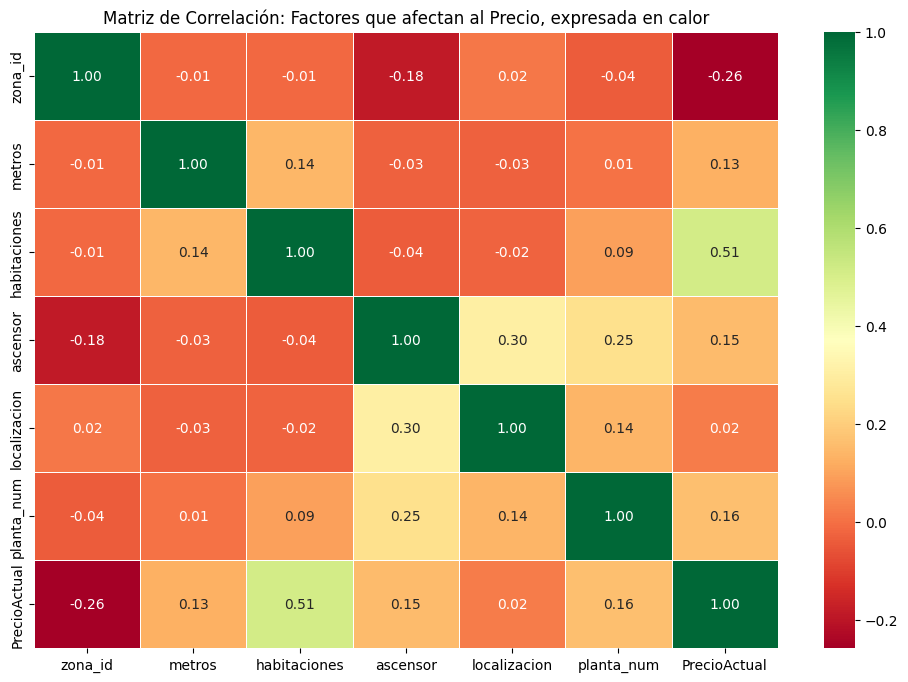

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# cols_para_corr = ['zona_id', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta_num', 'baños', 'PrecioActual']
cols_para_corr = ['zona_id', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta_num', 'PrecioActual']
matriz = df[cols_para_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title("Matriz de Correlación: Factores que afectan al Precio, expresada en calor")
plt.show()


In [27]:
# print(df['localizacion'].value_counts())
# print(df['ascensor'].value_counts())
# print(df['planta_num'].value_counts())
# print(df['metros'].value_counts())
# print(df['habitaciones'].value_counts())
# print(df['zona'].value_counts())
# print(df['PrecioActual'].value_counts())


In [28]:
# df['localizacion'] = (df['localizacion'] == 'EXTERIOR').astype(int)


# display(df[df['localizacion'] == 1].head(10))

In [29]:
# print("Valores reales en la columna:", df['localizacion'].unique())

In [30]:
valores_unicos = df['planta_num'].unique()
print(valores_unicos)

[ 5  1  2  0  3  6  4 16 13  9  7 10  8 14 11 12 -1 15 17 20 -2 27 22 21
 18]


In [31]:
zonas = sorted(df['zona'].unique())
print(df['zona'].value_counts())
print(zonas)

zona
barrio-de-salamanca    2018
centro                 1890
chamberi                796
chamartin               706
tetuan                  596
moncloa                 580
carabanchel             567
ciudad-lineal           537
puente-de-vallecas      526
retiro                  508
hortaleza               444
fuencarral              391
arganzuela              386
san-blas                335
latina                  331
villaverde              314
usera                   302
villa-de-vallecas       212
vicalvaro               193
moratalaz                97
barajas                  97
Name: count, dtype: int64
['arganzuela', 'barajas', 'barrio-de-salamanca', 'carabanchel', 'centro', 'chamartin', 'chamberi', 'ciudad-lineal', 'fuencarral', 'hortaleza', 'latina', 'moncloa', 'moratalaz', 'puente-de-vallecas', 'retiro', 'san-blas', 'tetuan', 'usera', 'vicalvaro', 'villa-de-vallecas', 'villaverde']


In [32]:
import pandas as pd

df_corr = df.copy()

zona_map = df_corr.groupby('zona')['PrecioActual'].mean()
df_corr['zona_impacto'] = df_corr['zona'].map(zona_map)

columnas_finales = ['zona_impacto', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta_num', 'PrecioActual']

correlacion = df_corr[columnas_finales].corr()['PrecioActual'].sort_values(ascending=False)

print(correlacion)




PrecioActual    1.000000
habitaciones    0.509278
zona_impacto    0.508667
planta_num      0.164917
ascensor        0.154931
metros          0.130661
localizacion    0.024791
Name: PrecioActual, dtype: float64


In [33]:

plt.figure(figsize=(10, 8))

sns.heatmap(matriz_completa, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matriz  (Mapa de Calor)")
plt.show()


NameError: name 'matriz_completa' is not defined

<Figure size 1000x800 with 0 Axes>